# #Install the lib
pip install --user --upgrade pip

pip install numpy opencv-python pandas seaborn tensorflow matplotlib scikit-learn scikit-image keras nengo python-time


In [1]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
from keras.callbacks import EarlyStopping


# #Logistic Regression, Supervised ML Algorithm

Execution Time: 0.379000186920166
Logistic Regression Accuracy: 0.55

Logistic Regression Metrics Table:
   Metric    Value
 Accuracy 0.550000
Precision 0.547945
   Recall 0.571429
 F1-score 0.559441


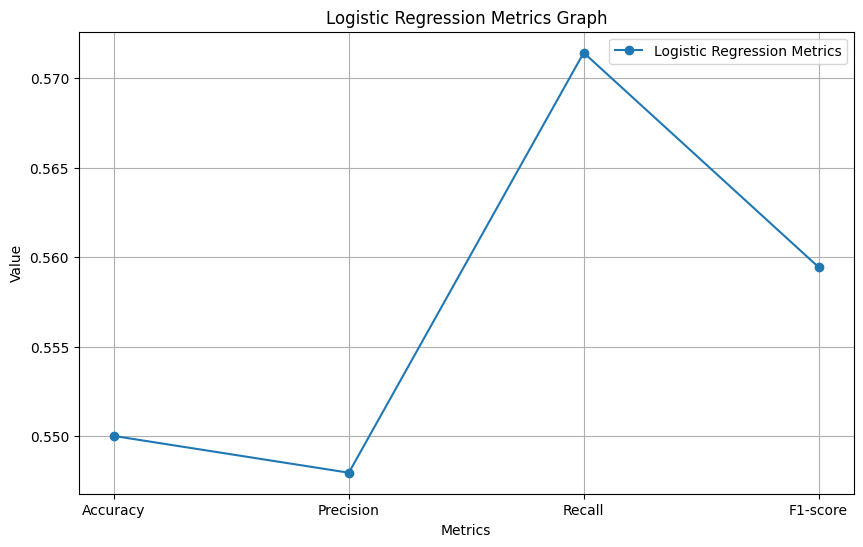

In [2]:

# Load data
base_dir = './CatsDogsDataset'
train_dir = os.path.join(base_dir, 'train')  
test_dir = os.path.join(base_dir, 'test')   

train_dir_cats = os.path.join(train_dir, 'cats') 
train_dir_dogs = os.path.join(train_dir, 'dogs') 
test_dir_cats = os.path.join(test_dir, 'cats') 
test_dir_dogs = os.path.join(test_dir, 'dogs') 

# Load images, turn to grayscale, resize to 64x64, then flatten to 1D array 
def load_images_and_preprocess(train_dir):
    images = []
    for filename in os.listdir(train_dir):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(train_dir, filename)
            img = cv2.imread(img_path)
            # Convert to grayscale
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Resize to 64x64
            resized_img = cv2.resize(gray_img, (64, 64))
            resized_img = resized_img.flatten()
            images.append(resized_img)
    return np.array(images)

cat_array = load_images_and_preprocess(train_dir_cats)
dog_array = load_images_and_preprocess(train_dir_dogs)

val_cat_array = load_images_and_preprocess(test_dir_cats)
val_dog_array = load_images_and_preprocess(test_dir_dogs)

# Combine the images and labels; labels are 0 for cat and 1 for dog
train_images = np.concatenate((cat_array, dog_array), axis=0)
train_labels = np.concatenate((np.zeros(len(cat_array)), np.ones(len(dog_array))), axis=0)
val_images = np.concatenate((val_cat_array, val_dog_array), axis=0)
val_labels = np.concatenate((np.zeros(len(val_cat_array)), np.ones(len(val_dog_array))), axis=0)

start_time = time.time()
# Apply Logistic Regression
lg = LogisticRegression(max_iter=1000)
lg_history = lg.fit(train_images, train_labels)
predictions = lg.predict(val_images)
end_time = time.time()
execution_time = end_time - start_time
print(f'Execution Time: {execution_time}')

# Evaluate Logistic Regression accuracy
lg_accuracy = accuracy_score(val_labels, predictions)
lg_precision = precision_score(val_labels, predictions)
lg_recall = recall_score(val_labels, predictions)
lg_f1 = f1_score(val_labels, predictions)

print(f'Logistic Regression Accuracy: {lg_accuracy}')

# Create DataFrame for Logistic Regression metrics
lg_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [lg_accuracy, lg_precision, lg_recall, lg_f1]
})

print("\nLogistic Regression Metrics Table:")
print(lg_metrics_df.to_string(index=False))

# Plot Logistic Regression metrics
plt.figure(figsize=(10, 6))
plt.plot(lg_metrics_df["Metric"], lg_metrics_df["Value"], marker='o', linestyle='-', label="Logistic Regression Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Logistic Regression Metrics Graph")
plt.legend()
plt.grid()
plt.show()


# #K-Means clustering, Unsupervised ML Algorithm

Execution Time: 0.3746044635772705
K-Means Accuracy: 0.4785714285714286

K-Means Metrics Table:
   Metric    Value
 Accuracy 0.478571
Precision 0.472727
   Recall 0.371429
 F1-score 0.416000


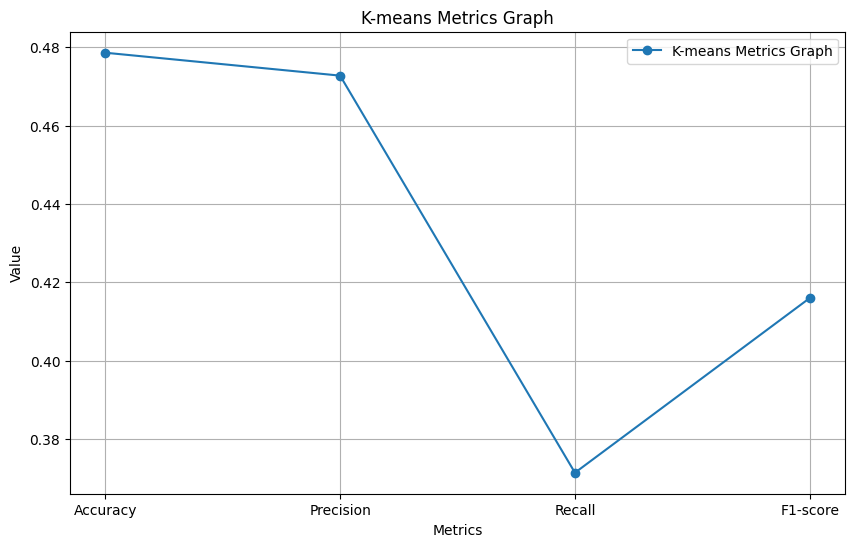

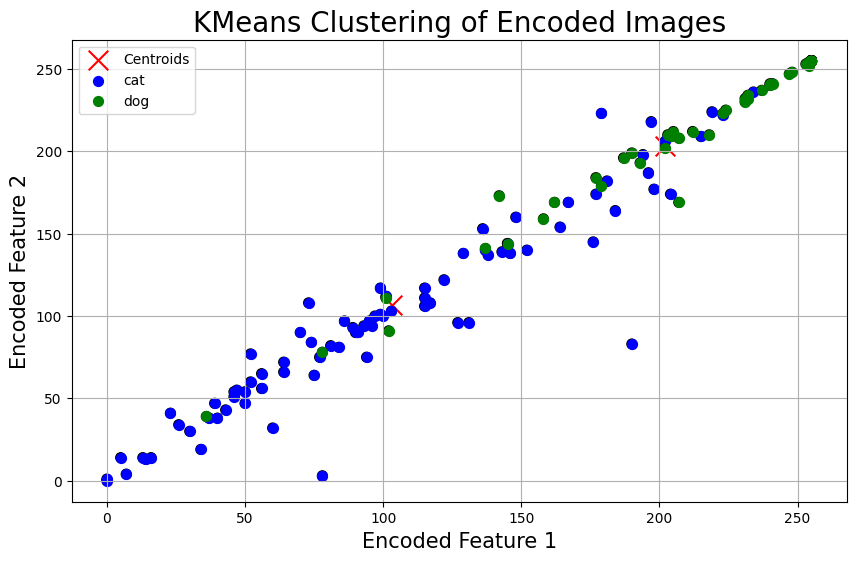

In [3]:

# Apply K-Means clustering

start_time = time.time()
kmeans = KMeans(n_clusters=2, random_state=1024)
kmeans_history = kmeans.fit(train_images)

# Predict clusters
test_labels_kmeans = kmeans.predict(val_images)

end_time = time.time()
execution_time = end_time - start_time

print(f'Execution Time: {execution_time}')
# Calculate K-Means accuracy
kmeans_accuracy = accuracy_score(val_labels, test_labels_kmeans)
kmeans_precision = precision_score(val_labels, test_labels_kmeans)
kmeans_recall = recall_score(val_labels, test_labels_kmeans)
kmeans_f1 = f1_score(val_labels, test_labels_kmeans)

print(f'K-Means Accuracy: {kmeans_accuracy}')

# Create DataFrame for K-Means metrics
kmeans_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [kmeans_accuracy, kmeans_precision, kmeans_recall, kmeans_f1]
})

print("\nK-Means Metrics Table:")
print(kmeans_metrics_df.to_string(index=False))


# Plot Logistic Regression metrics
plt.figure(figsize=(10, 6))
plt.plot(kmeans_metrics_df["Metric"], kmeans_metrics_df["Value"], marker='o', linestyle='-', label="K-means Metrics Graph")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("K-means Metrics Graph")
plt.legend()
plt.grid()
plt.show()

# Visualization of KMeans Clustering
plt.figure(figsize=(10, 6))

# Use val_images for scatter plot since we want to visualize the validation results
encoded = val_images  # Use the validation images

# Scatter plot of the encoded features
plt.scatter(encoded[:, 0], encoded[:, 1], c=test_labels_kmeans, cmap='viridis', marker='o', edgecolor='k', s=50)

# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=200, label='Centroids')

# Manually set colors for cat and dog
cat_color = 'b'  # blue for cat
dog_color = 'g'  # green for dog

# Create a scatter plot for cats and dogs separately
plt.scatter(encoded[test_labels_kmeans == 0, 0], encoded[test_labels_kmeans == 0, 1], c=cat_color, label='cat', marker='o', s=50)
plt.scatter(encoded[test_labels_kmeans == 1, 0], encoded[test_labels_kmeans == 1, 1], c=dog_color, label='dog', marker='o', s=50)

# Add legend and grid
plt.legend()
plt.grid(True)
plt.title("KMeans Clustering of Encoded Images", fontsize=20)
plt.xlabel("Encoded Feature 1", fontsize=15)
plt.ylabel("Encoded Feature 2", fontsize=15)
plt.show()

# #Autoencoder, Unsupervised DL Algorithm

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │       266,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,448 (2.02 MB)

 Trainable params: 528,448 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6810 - val_loss: 0.6507
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6461 - val_loss: 0.6437
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6426 - val_loss: 0.6420
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6400 - val_loss: 0.6383
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6269 - val_loss: 0.6336
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6187 - val_loss: 0.6256
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6224 - val_loss: 0.6217
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6106 - val_loss: 0.6201
Epoch 9/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6180 - val_loss: 0.6203
Epoch 10/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6176 - val_loss: 0.6173
Epoch 11/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6097 - val_loss: 0.6150
Epoch 12/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6055 - val_l

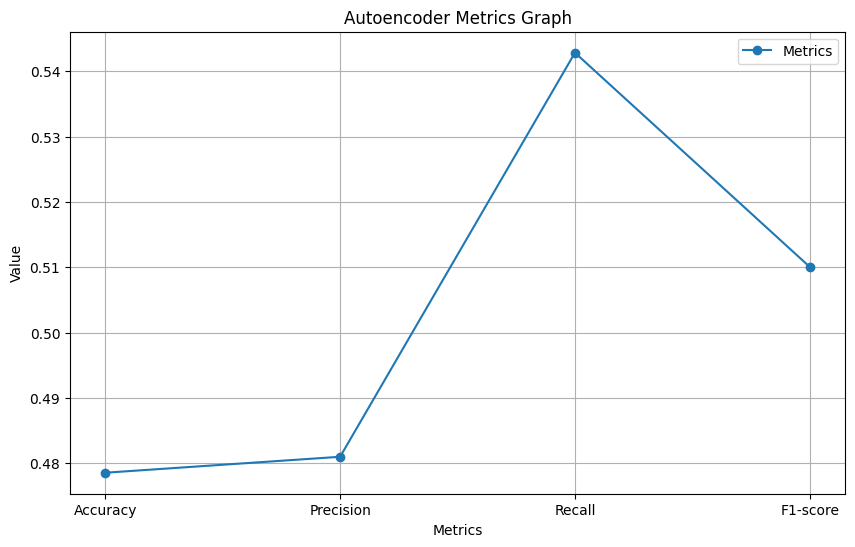

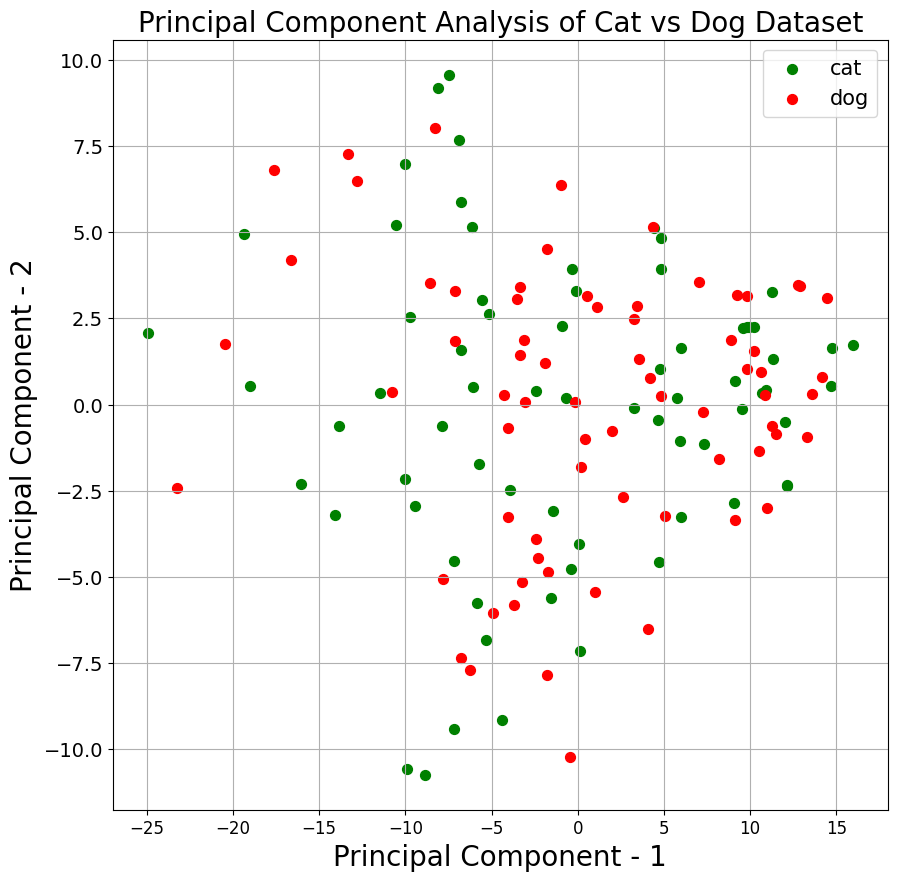

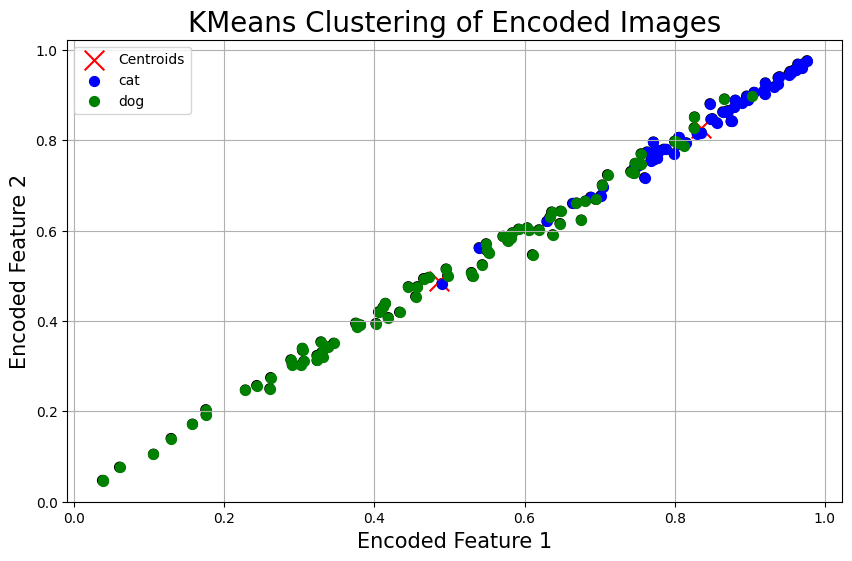

In [8]:
def read_preprocess_img(dir_path):
    images = []

    for img_path in os.listdir(dir_path):
        if img_path.endswith(".jpg"):
            img_path = os.path.join(dir_path, img_path)
            img = cv2.imread(img_path)
            # resize
            processed_img = cv2.resize(img, (64, 64))
            # greyscale
            processed_img = cv2.cvtColor(processed_img, cv2.COLOR_BGR2GRAY)
            # normalize to range [0, 1]
            processed_img = processed_img.astype('float32')/255
            # flatten
            processed_img = processed_img.flatten()

            images.append(processed_img)

    return np.array(images)

train_cat = read_preprocess_img(train_dir_cats)
train_dog = read_preprocess_img(train_dir_dogs)
test_cat = read_preprocess_img(test_dir_cats)
test_dog = read_preprocess_img(test_dir_dogs)

train_images = np.concatenate((train_cat, train_dog), axis=0)
test_images = np.concatenate((test_cat, test_dog),axis=0)

# create labels for accuracy assessment
train_labels = np.concatenate((np.zeros(len(train_cat)), np.ones(len(train_dog))), axis=0)
test_labels = np.concatenate((np.zeros(len(test_cat)), np.ones(len(test_dog))), axis=0)

# build & define autoencoder

encoding_dim = 64

# add more layers if i know what the fuck im doing which i dont
# also change the activation functions probably
input_img = Input(shape=(4096,))
encoded = Dense(encoding_dim, activation='relu')(input_img)
decoded = Dense(4096, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

start_time = time.time()
# train autoencoder
autoencoder.fit(
    train_images, train_images,
    epochs=20,  # Reduced epochs
    batch_size=16,  # Reduced batch size
    shuffle=True,
    validation_data=(test_images, test_images)
)


# Make predictions
encoded = autoencoder.predict(test_images)


# KMeans clustering
kmeans = KMeans(n_clusters=2)
pca_history = kmeans.fit(encoded)  # Fit KMeans on encoded features
labels = kmeans.labels_

# Accuracy assessment
accuracy = accuracy_score(test_labels, labels)
print(f"Accuracy: {accuracy:.4f}")

# Visualization of graph

end_time = time.time()
execution_time = end_time - start_time

print(f'Execution Time: {execution_time}')
# After KMeans clustering, evaluate accuracy and other metrics
accuracy = accuracy_score(test_labels, labels)
precision = precision_score(test_labels, labels)
recall = recall_score(test_labels, labels)
f1 = f1_score(test_labels, labels)

# Create DataFrame for Loss and Accuracy
Autoencoder_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

print("\nTrain and Test Accuracy Table:")
print(Autoencoder_metrics_df.to_string(index=False))

# Plot Loss and Accuracy Graph
plt.figure(figsize=(10, 6))
plt.plot(Autoencoder_metrics_df["Metric"], Autoencoder_metrics_df["Value"], marker='o', linestyle='-', label="Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("Autoencoder Metrics Graph")
plt.legend()
plt.grid()
plt.show()

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(encoded)
principal_df = pd.DataFrame(data=principalComponents, columns=['Principal Component 1', 'Principal Component 2'])

# Visualization
plt.figure(figsize=(10, 10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1', fontsize=20)
plt.ylabel('Principal Component - 2', fontsize=20)
plt.title("Principal Component Analysis of Cat vs Dog Dataset", fontsize=20)

# Define targets and colors
targets = ['cat', 'dog']
colors = ['g', 'r']

# Scatter plot for each target
for target, color in zip(targets, colors):
    indicesToKeep = test_labels == (0 if target == 'cat' else 1)
    plt.scatter(principal_df.loc[indicesToKeep, 'Principal Component 1'],
                principal_df.loc[indicesToKeep, 'Principal Component 2'],
                c=color, s=50, label=target)

# Add legend
plt.legend(targets, prop={'size': 15})
plt.grid(True)
plt.show()

# # plot results
# Visualization of KMeans Clustering
plt.figure(figsize=(10, 6))

# Scatter plot of the encoded features
plt.scatter(encoded[:, 0], encoded[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50)

# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=200, label='Centroids')

# Manually set the colors for cat and dog
cat_color = 'b'  # green for cat
dog_color = 'g'  # red for dog

# Create a scatter plot for cats and dogs separately
plt.scatter(encoded[labels == 0, 0], encoded[labels == 0, 1], c=cat_color, label='cat', marker='o', s=50)
plt.scatter(encoded[labels == 1, 0], encoded[labels == 1, 1], c=dog_color, label='dog', marker='o', s=50)

# Add legend and grid
plt.legend()
plt.grid(True)
plt.title("KMeans Clustering of Encoded Images", fontsize=20)
plt.xlabel("Encoded Feature 1", fontsize=15)
plt.ylabel("Encoded Feature 2", fontsize=15)
plt.show()

# #CNN, Supervised DL Algorithm

Epoch 1/20


c:\Users\users1\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\users1\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.4880 - loss: 29.2762 - val_accuracy: 0.4857 - val_loss: 0.7154
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.4563 - loss: 0.7300 - val_accuracy: 0.5143 - val_loss: 0.6896
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.5363 - loss: 0.6924 - val_accuracy: 0.5143 - val_loss: 0.6953
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.4831 - loss: 0.6981 - val_accuracy: 0.4571 - val_loss: 0.6937
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.4659 - loss: 0.6969 - val_accuracy: 0.5571 - val_loss: 0.6857
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5307 - loss: 0.6930 - val_accuracy: 0.5643 - val_loss: 0.6842
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.4741 - loss: 0.6939 - val_accuracy: 0.5500 - val_loss: 0.6887
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.5678 - loss: 0.6853 - val_accuracy: 0.5429 - val

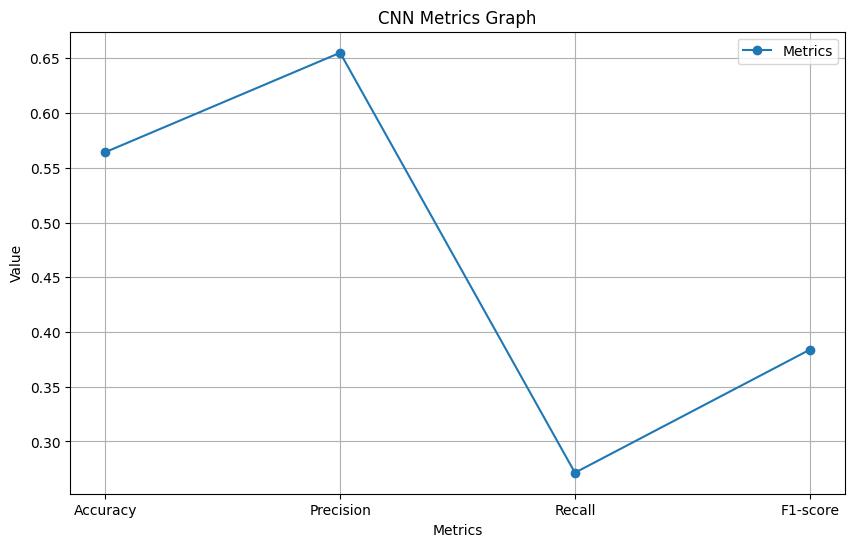

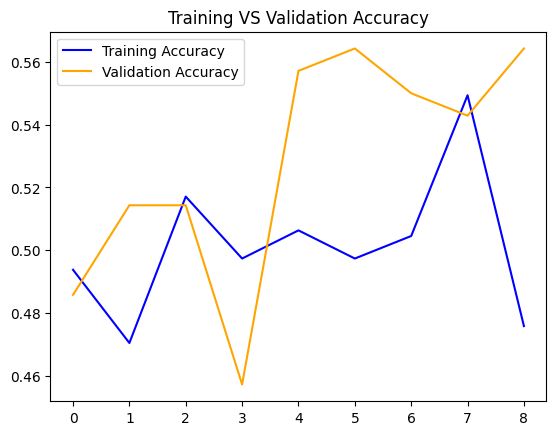

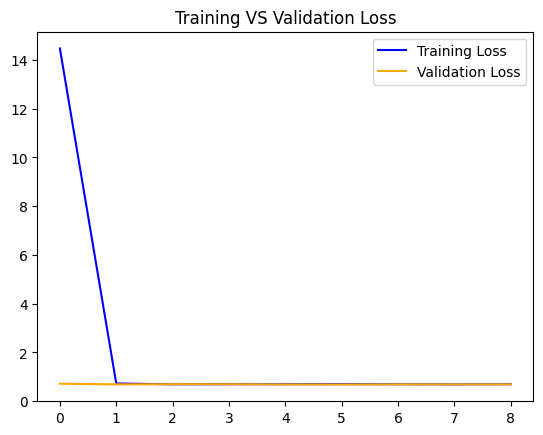

In [13]:
resize = 100

# Function to apply Sobel filter
def apply_sobel(img):
    img = np.array(img)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.hypot(sobelx, sobely)
    sobel = (sobel / sobel.max() * 255).astype(np.uint8)
    return sobel

# Load and preprocess images
def load_images_and_preprocess(train_dir):
    images = []
    labels = []
    for filename in os.listdir(train_dir):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(train_dir, filename)
            img_n = cv2.imread(img_path)
            img_n = cv2.resize(img_n, (resize, resize))
            img_n = cv2.cvtColor(img_n, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
            img_n = cv2.GaussianBlur(img_n, (3, 3), 0)
            img_n = apply_sobel(img_n)
            images.append(img_n)
            labels.append(0 if 'cat' in filename else 1)
    return np.array(images), np.array(labels)

# Load training data
cat_array, cat_labels = load_images_and_preprocess(train_dir_cats)
dog_array, dog_labels = load_images_and_preprocess(train_dir_dogs)

# Combine images and labels
train_images = np.concatenate((cat_array, dog_array), axis=0)
train_labels = np.concatenate((cat_labels, dog_labels), axis=0)

# Convert labels to one-hot encoding
train_labels = to_categorical(train_labels, num_classes=2)

# Load validation images
val_cat_array, val_cat_labels = load_images_and_preprocess(test_dir_cats)
val_dog_array, val_dog_labels = load_images_and_preprocess(test_dir_dogs)

# Combine validation images and labels
val_images = np.concatenate((val_cat_array, val_dog_array), axis=0)
val_labels = np.concatenate((val_cat_labels, val_dog_labels), axis=0)

# Convert validation labels to one-hot encoding
val_labels = to_categorical(val_labels, num_classes=2)

# Reshape for CNN with 1 channel
train_images = train_images.reshape(-1, resize, resize, 1)
val_images = val_images.reshape(-1, resize, resize, 1)

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(resize, resize, 1)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dropout(0.5),  # Add dropout to reduce overfitting
    layers.Dense(512, activation='relu'),
    layers.Dense(2, activation='softmax')
])

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

start_time = time.time()
# Train the model
cnn_history = model.fit(
    train_datagen.flow(train_images, train_labels, batch_size=32),
    validation_data=(val_images, val_labels),
    epochs=20,
    callbacks=[early_stopping]
)


acc = cnn_history.history['accuracy']
val_acc = cnn_history.history['val_accuracy']
loss = cnn_history.history['loss']
val_loss = cnn_history.history['val_loss']

epochs = range(len(acc))

# Evaluate the model
val_predictions = model.predict(val_images)
val_predictions_classes = np.argmax(val_predictions, axis=1)
val_labels_classes = np.argmax(val_labels, axis=1)

end_time = time.time()
execution_time = end_time - start_time

print(f'Execution Time: {execution_time}')
# Calculate metrics
accuracy = accuracy_score(val_labels_classes, val_predictions_classes)
precision = precision_score(val_labels_classes, val_predictions_classes)
recall = recall_score(val_labels_classes, val_predictions_classes)
f1 = f1_score(val_labels_classes, val_predictions_classes)

# Create DataFrame for Loss and Accuracy
cNN_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

print("\nTrain and Test Accuracy Table:")
print(cNN_metrics_df.to_string(index=False))

# Plot Loss and Accuracy Graph
plt.figure(figsize=(10, 6))
plt.plot(cNN_metrics_df["Metric"], cNN_metrics_df["Value"], marker='o', linestyle='-', label="Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("CNN Metrics Graph")
plt.legend()
plt.grid()
plt.show()

plt.plot(epochs, acc, color='blue', label='Training Accuracy')
plt.plot(epochs, val_acc, color='orange', label='Validation Accuracy')
plt.title('Training VS Validation Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss, color='blue', label='Training Loss')
plt.plot(epochs, val_loss, color='orange', label='Validation Loss')
plt.title('Training VS Validation Loss')
plt.legend()
plt.show()

# #SNN

c:\Users\users1\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Class names: ['Cat', 'Dog']


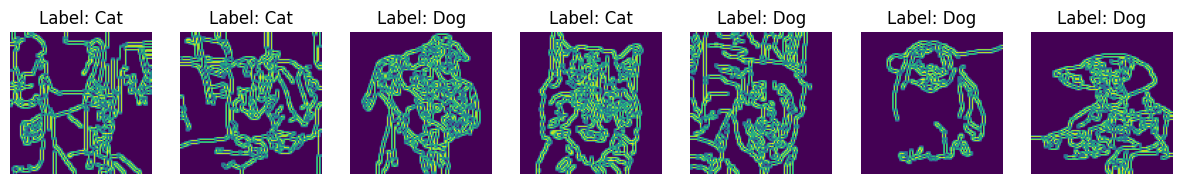

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.4616 - loss: 100.7426 - val_accuracy: 0.5071 - val_loss: 16.1133
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.5231 - loss: 9.2104 - val_accuracy: 0.5357 - val_loss: 1.0943
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.6223 - loss: 0.8734 - val_accuracy: 0.5429 - val_loss: 0.7702
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.6909 - loss: 0.5842 - val_accuracy: 0.4857 - val_loss: 0.7423
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.7951 - loss: 0.4668 - val_accuracy: 0.6143 - val_loss: 0.6882
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.8634 - loss: 0.3542 - val_accuracy: 0.6214 - val_loss: 0.7903
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.8973 - loss: 0.2738 - val_accuracy: 0.5929 - val_loss: 0.9428
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.9420 - loss: 0.1739 - val_accuracy: 0.5500 - val_lo

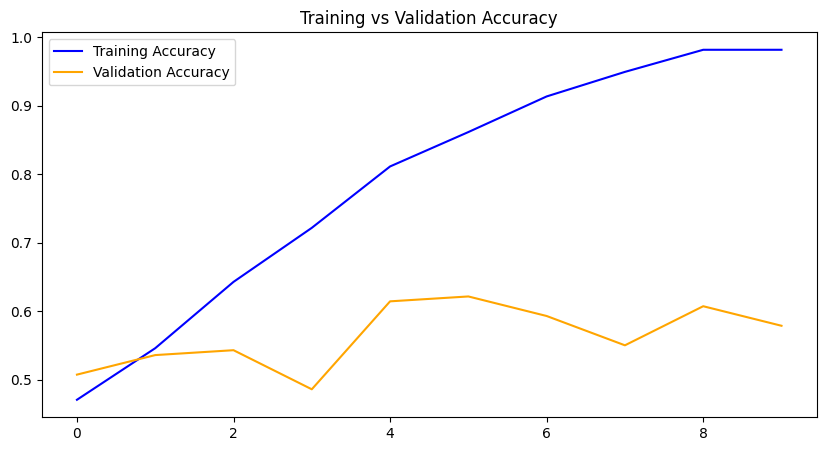

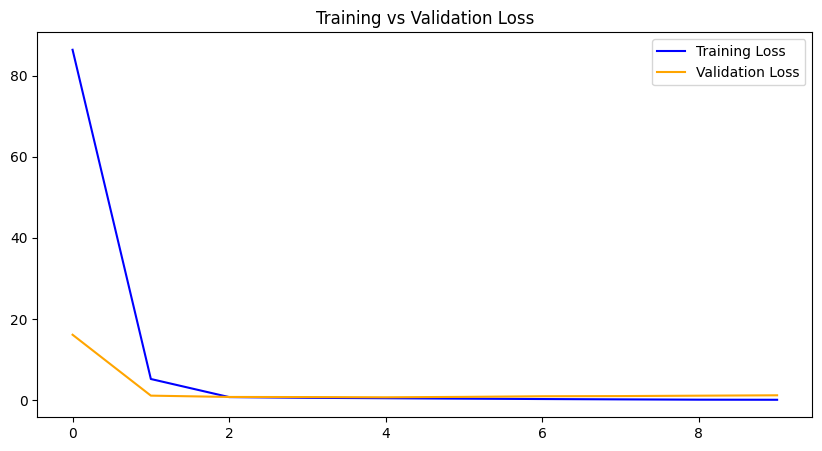

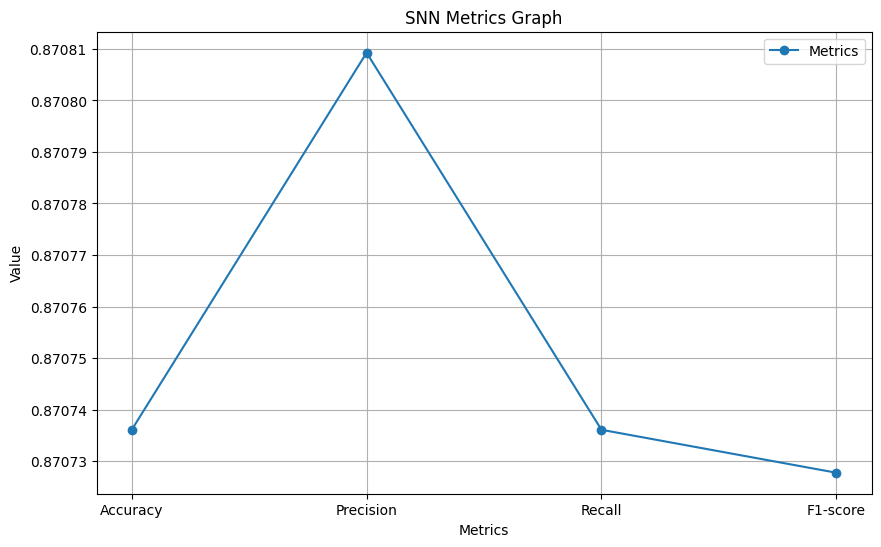

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


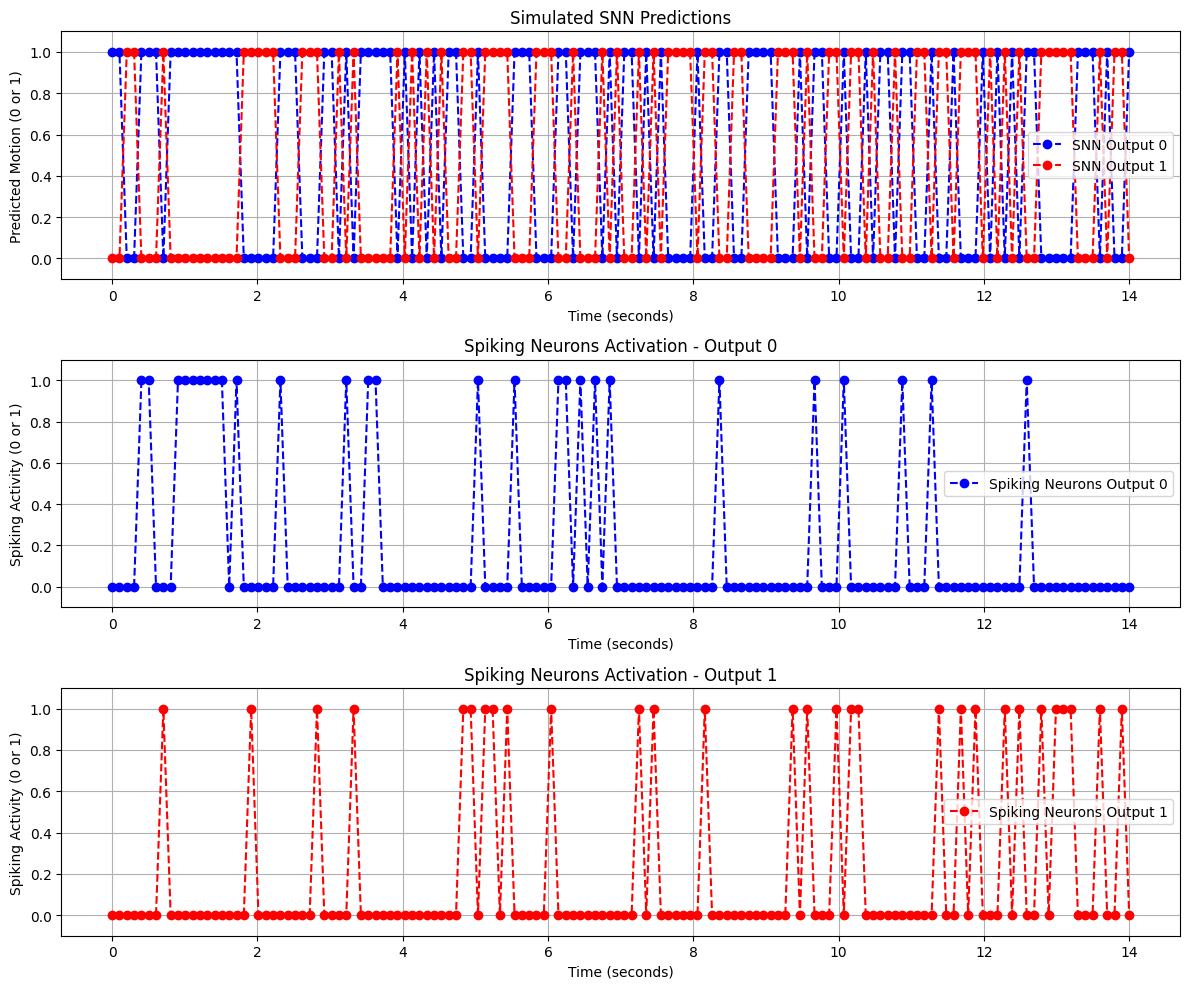

In [6]:
# Define image size
resize = 100

# Function to apply Sobel filter
def apply_sobel(img):
    img = np.array(img)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.hypot(sobelx, sobely)
    sobel = (sobel / sobel.max() * 255).astype(np.uint8)
    return sobel

# Load and preprocess images
def load_images_and_preprocess(train_dir):
    images = []
    labels = []
    for filename in os.listdir(train_dir):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(train_dir, filename)
            img_n = cv2.imread(img_path)
            img_n = cv2.resize(img_n, (resize, resize))
            img_n = cv2.cvtColor(img_n, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
            img_n = cv2.GaussianBlur(img_n, (3, 3), 0)
            img_n = cv2.Canny(img_n, 50, 150)
            img_n = apply_sobel(img_n)
            images.append(img_n)
            labels.append(0 if 'cat' in filename else 1)
    return np.array(images), np.array(labels)

# Load data directories
base_dir = './CatsDogsDataset'
train_dir = os.path.join(base_dir, 'train')  
test_dir = os.path.join(base_dir, 'test')   

train_dir_cats = os.path.join(train_dir, 'cats') 
train_dir_dogs = os.path.join(train_dir, 'dogs') 
test_dir_cats = os.path.join(test_dir, 'cats') 
test_dir_dogs = os.path.join(test_dir, 'dogs') 

# Load training data
cat_array, cat_labels = load_images_and_preprocess(train_dir_cats)
dog_array, dog_labels = load_images_and_preprocess(train_dir_dogs)

# Combine images and labels
train_images = np.concatenate((cat_array, dog_array), axis=0)
train_labels = np.concatenate((cat_labels, dog_labels), axis=0)

# Convert labels to one-hot encoding
train_labels = to_categorical(train_labels, num_classes=2)

# Load validation images
val_cat_array, val_cat_labels = load_images_and_preprocess(test_dir_cats)
val_dog_array, val_dog_labels = load_images_and_preprocess(test_dir_dogs)

# Combine validation images and labels
val_images = np.concatenate((val_cat_array, val_dog_array), axis=0)
val_labels = np.concatenate((val_cat_labels, val_dog_labels), axis=0)

# Convert validation labels to one-hot encoding
val_labels = to_categorical(val_labels, num_classes=2)

# Reshape for CNN with 1 channel
train_images = train_images.reshape(-1, resize, resize, 1)
val_images = val_images.reshape(-1, resize, resize, 1)

start_time = time.time()
# Define a CNN model with Spiking Activation
class SpikingActivation(tf.keras.layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.nn.relu(inputs) * tf.cast(tf.random.uniform(tf.shape(inputs)) > 0.5, tf.float32)

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(resize, resize, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128),
    SpikingActivation(),
    Dense(2, activation='softmax')
])


import random

# ------------------- Performance Visualization -------------------
resize = 64  # Resize images for display

# Function to display images with class names
def display_images_with_labels(images, labels, class_names, num_images):
    # Randomly select indices
    indices = random.sample(range(len(images)), num_images)
    
    # Create a figure to display the images
    plt.figure(figsize=(15, 3))
    
    for i, idx in enumerate(indices):
        # Get the image and label
        image = images[idx]  # Image is already normalized and resized (150x150)
        label = np.argmax(labels[idx])  # Convert one-hot to label index
        
        # Plot the image
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)  # No colormap since images are colored (RGB)
        plt.title(f"Label: {class_names[label]}")
        plt.axis('off')
    
    plt.show()

# Access class names
class_names = ["Cat", "Dog"]
print("Class names:", class_names)

# Call the function to display 7 random images with class names
display_images_with_labels(train_images, train_labels, class_names, num_images=7)

cnn_model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)


# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop if no improvement for 5 epochs
    restore_best_weights=True  # Restore best model weights
)

# Train the model
history = cnn_model.fit(
    train_images, train_labels,batch_size=64,
    validation_data=(val_images, val_labels),
    epochs=20,
    callbacks=[early_stopping]
)


print("Hybrid CNN-SNN Training Completed!")


# Extract accuracy and loss from training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

# Calculate metrics
val_predictions = cnn_model.predict(train_images)
val_predictions_classes = np.argmax(val_predictions, axis=1)
val_labels_classes = np.argmax(train_labels, axis=1)


end_time = time.time()
execution_time = end_time - start_time
print(f'Execution Time: {execution_time}')

accuracy = accuracy_score(val_labels_classes, val_predictions_classes)
precision = precision_score(val_labels_classes, val_predictions_classes, average='weighted')
recall = recall_score(val_labels_classes, val_predictions_classes, average='weighted')
f1 = f1_score(val_labels_classes, val_predictions_classes, average='weighted')

# Create DataFrame for Loss and Accuracy
sNN_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

print("\nTrain and Test Accuracy Table:")
print(sNN_metrics_df.to_string(index=False))

# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, color='blue', label='Training Accuracy')
plt.plot(epochs, val_acc, color='orange', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, color='blue', label='Training Loss')
plt.plot(epochs, val_loss, color='orange', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Plot Metrics
plt.figure(figsize=(10, 6))
plt.plot(sNN_metrics_df["Metric"], sNN_metrics_df["Value"], marker='o', linestyle='-', label="Metrics")
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.title("SNN Metrics Graph")
plt.legend()
plt.grid()
plt.show()

# Get predictions from the trained CNN model
predictions = cnn_model.predict(val_images)

# Simulated SNN output based on CNN predictions
threshold = 0.5
snn_output_0 = (predictions[:, 0] > threshold).astype(float)  # SNN Output for class 0
snn_output_1 = (predictions[:, 1] > threshold).astype(float)  # SNN Output for class 1

# Simulate spiking behavior
spike_threshold = 0.7  # Example threshold for spiking behavior
spiking_neurons_0 = (predictions[:, 0] > spike_threshold).astype(float)  # Spiking neurons for class 0
spiking_neurons_1 = (predictions[:, 1] > spike_threshold).astype(float)  # Spiking neurons for class 1

# Time vector for plotting
time_vector = np.linspace(0, len(snn_output_0) / 10, len(snn_output_0))  # Assuming 10 samples/second

# Plotting SNN predictions and spiking neurons
plt.figure(figsize=(12, 10))

# SNN Output Plot
plt.subplot(3, 1, 1)
plt.plot(time_vector, snn_output_0, label='SNN Output 0', marker='o', linestyle='--', color='blue')
plt.plot(time_vector, snn_output_1, label='SNN Output 1', marker='o', linestyle='--', color='red')
plt.title('Simulated SNN Predictions')
plt.xlabel('Time (seconds)')
plt.ylabel('Predicted Motion (0 or 1)')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

# Spiking Neurons Plot for Output 0
plt.subplot(3, 1, 2)
plt.plot(time_vector, spiking_neurons_0, label='Spiking Neurons Output 0', marker='o', linestyle='--', color='blue')
plt.title('Spiking Neurons Activation - Output 0')
plt.xlabel('Time (seconds)')
plt.ylabel('Spiking Activity (0 or 1)')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

# Spiking Neurons Plot for Output 1
plt.subplot(3, 1, 3)
plt.plot(time_vector, spiking_neurons_1, label='Spiking Neurons Output 1', marker='o', linestyle='--', color='red')
plt.title('Spiking Neurons Activation - Output 1')
plt.xlabel('Time (seconds)')
plt.ylabel('Spiking Activity (0 or 1)')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# #Five Model’s Performance of Accuracy

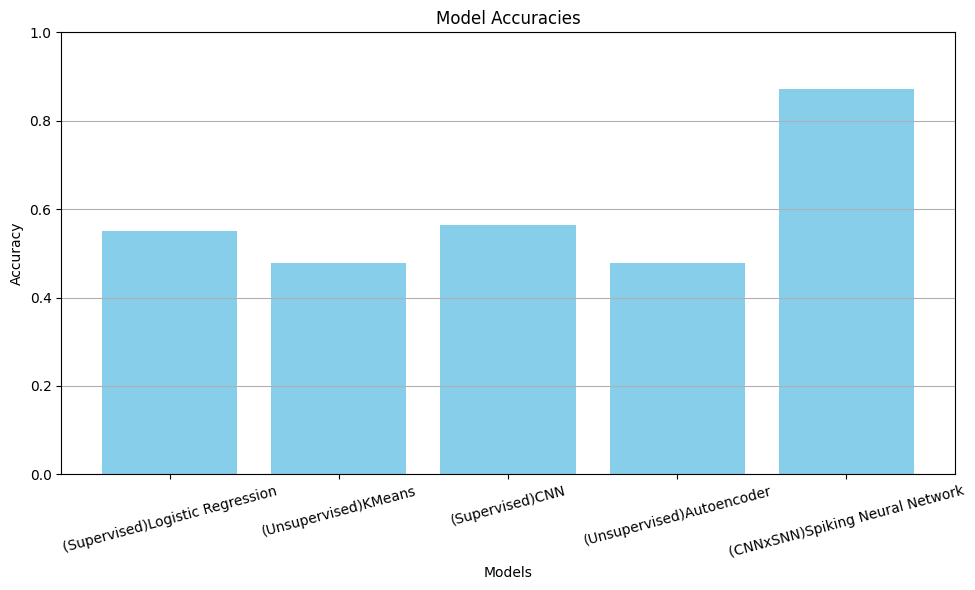

In [14]:
accuracies = {
    "(Supervised)Logistic Regression": lg_metrics_df.loc[lg_metrics_df['Metric'] == 'Accuracy', 'Value'].values[0],
    "(Unsupervised)KMeans": kmeans_metrics_df.loc[kmeans_metrics_df['Metric'] == 'Accuracy', 'Value'].values[0],
    "(Supervised)CNN": cNN_metrics_df.loc[cNN_metrics_df['Metric'] == 'Accuracy', 'Value'].values[0],
    "(Unsupervised)Autoencoder": Autoencoder_metrics_df.loc[Autoencoder_metrics_df['Metric'] == 'Accuracy', 'Value'].values[0],
    "(CNNxSNN)Spiking Neural Network": sNN_metrics_df.loc[sNN_metrics_df['Metric'] == 'Accuracy', 'Value'].values[0],
}

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])

# Plotting the accuracies
plt.figure(figsize=(10, 6))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'], color='skyblue')
plt.title('Model Accuracies')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Assuming accuracy is between 0 and 1
plt.xticks(rotation=15)
plt.grid(axis='y')

# Show the plot
plt.tight_layout()
plt.show()